# Difference-in-Differences (DiD) Analysis

## Overview

This notebook estimates the association between hospital mergers and cost outcomes using a staggered DiD design with merger-year timing.

Before running this model, we checked extended pre-trends using a longer pre-period window in the separate pre-trend notebook. Those diagnostics did not fully support parallel trends in the full sample or subgroup checks.

Because of that, the DiD estimates here are interpreted as suggestive evidence, not clean causal estimates.

## Staggered DiD Design Context

Hospitals enter merger exposure in different years, so treatment timing is staggered across units.

The model compares treated hospitals before and after merger against never-treated hospitals over the same calendar years, while controlling for:

- Hospital fixed effects (time-invariant hospital differences)
- Year fixed effects (common shocks over time)

The treatment indicator for estimation is `treated_post`, equal to 1 when a treated hospital is observed in fiscal years on or after its merger year.

## Objectives

- Build a clean hospital-year sample from the full panel
- Construct outcome and treatment-timing variables for staggered DiD
- Estimate the main DiD model with hospital and year fixed effects
- Cluster standard errors at the hospital level
- Report the main coefficient in log points and approximate percent terms
- Interpret results with caution based on pre-trend findings

## Dataset Description

The notebook uses the full hospital panel in `01_data/hospital_analysis.csv`.

Core variables include `PRVDR_NUM`, `fiscal_year`, `treated`, `merger_year`, and `cost_per_discharge`.

The primary outcome is transformed as `log(cost_per_discharge)`.

## Key Considerations

- Parallel trends was not fully supported in extended diagnostics
- DiD estimates may still capture residual pre-existing trend differences
- Fixed effects improve comparability but do not fix pre-trend violations by themselves
- Results should be read as directional evidence, not definitive causal proof

## Outcome

By the end of this notebook, you get a descriptive trend plot, a main staggered DiD estimate, and a short interpretation that explicitly states the key limitation from pre-trend checks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.regression.linear_model import OLS

## Data and sample construction

Use the same full-sample data source and cleaning steps used in the extended pre-trend notebook (`01_data/hospital_analysis.csv`).

In [2]:
# Data and sample construction
df = pd.read_csv(
    "/Users/tonantzinrealrojas/Documents/IDS_701_UDS/IDS_701_final_project/01_data/hospital_analysis.csv"
)  # "../../01_data/hospital_analysis.csv")

# Keep only variables needed for the DiD analysis
did_cols = [
    "ccn",
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "merger_year",
    "post_merger",
    "cost_per_discharge",
]
existing_did_cols = [col for col in did_cols if col in df.columns]
df = df[existing_did_cols].copy()

# Minimal cleaning for regression-ready sample
for col in [
    "fiscal_year",
    "treated",
    "merger_year",
    "post_merger",
    "cost_per_discharge",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=["fiscal_year", "treated", "post_merger", "cost_per_discharge"]
).copy()
df = df[df["treated"].isin([0, 1])].copy()
df = df[df["cost_per_discharge"] >= 0].copy()

print("DiD sample shape:", df.shape)
print("Treated hospitals:", df.loc[df["treated"] == 1, "PRVDR_NUM"].nunique())
print("Never-treated hospitals:", df.loc[df["treated"] == 0, "PRVDR_NUM"].nunique())

df.head()

DiD sample shape: (53354, 7)
Treated hospitals: 1242
Never-treated hospitals: 5219


,ccn,PRVDR_NUM,fiscal_year,treated,merger_year,post_merger,cost_per_discharge
0,271326,271326,2011,0,NaN,0,55882.083871
1,13025,13025,2011,0,NaN,0,16549.966527
2,103037,103037,2011,0,NaN,0,14775.198540
3,103042,103042,2011,0,NaN,0,17482.771906
4,141990,141990,2011,0,NaN,0,10585.909091


## Outcome construction

Build `log(cost_per_discharge)` and show a descriptive trend plot by treatment group over time.

Model-ready sample shape: (53354, 8)


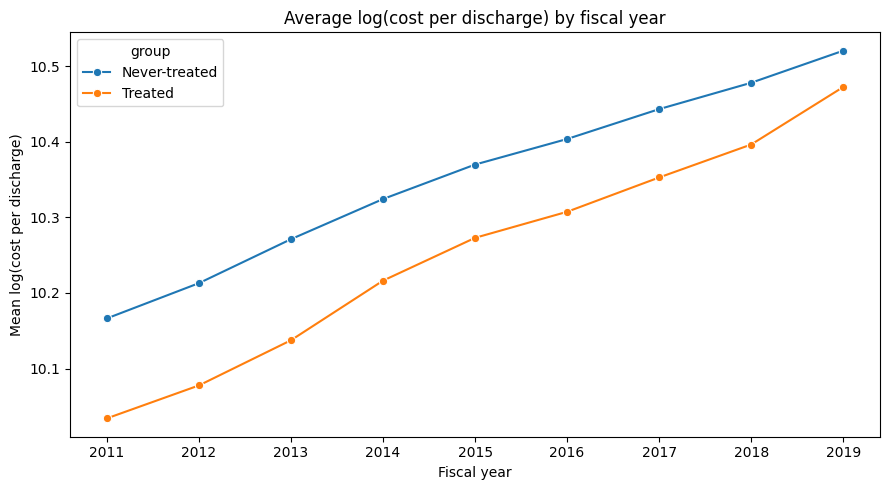

In [3]:
# Outcome construction
work_df = df.copy()

# Keep valid outcome values for log transformation
work_df = work_df[work_df["cost_per_discharge"] > 0].copy()
work_df["log_cost_per_discharge"] = np.log(work_df["cost_per_discharge"])

# Keep rows usable for the DiD model
work_df = work_df.dropna(
    subset=["ccn", "fiscal_year", "treated", "post_merger", "log_cost_per_discharge"]
).copy()

print("Model-ready sample shape:", work_df.shape)

# Descriptive plot by fiscal year
plot_df = work_df.groupby(["fiscal_year", "treated"], as_index=False)[
    "log_cost_per_discharge"
].mean()
plot_df["group"] = plot_df["treated"].map({0: "Never-treated", 1: "Treated"})

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="fiscal_year",
    y="log_cost_per_discharge",
    hue="group",
    marker="o",
)
plt.title("Average log(cost per discharge) by fiscal year")
plt.xlabel("Fiscal year")
plt.ylabel("Mean log(cost per discharge)")
plt.tight_layout()

# out_dir = Path("../../05_outputs/figures")
# out_dir.mkdir(parents=True, exist_ok=True)
out_dir = Path("../04_outputs/figures")
plt.savefig(out_dir / "did_avg_log_cost_full_sample.png", dpi=200)
plt.show()
plt.close()

## Main staggered DiD model

Estimate a staggered DiD with merger-year timing using hospital fixed effects and year fixed effects, with standard errors clustered at the hospital level.

In [4]:
# Regression sample for DiD
reg_df = work_df.dropna(
    subset=["fiscal_year", "ccn", "treated", "post_merger", "log_cost_per_discharge"]
).copy()

reg_df["fiscal_year"] = reg_df["fiscal_year"].astype(int)
reg_df["ccn"] = reg_df["ccn"].astype(int)
reg_df["treated_post"] = reg_df["treated"] * reg_df["post_merger"]

print("Regression sample shape:", reg_df.shape)

Regression sample shape: (53354, 9)


In [5]:
# Main staggered DiD model (two-way FE via residualization)
def two_way_residualize(values, entity, time, max_iter=100, tol=1e-10):
    resid = values.astype(float).copy()
    for _ in range(max_iter):
        prev = resid.copy()
        resid -= pd.Series(resid).groupby(entity).transform("mean").to_numpy()
        resid -= pd.Series(resid).groupby(time).transform("mean").to_numpy()
        if np.max(np.abs(resid - prev)) < tol:
            break
    return resid


y = reg_df["log_cost_per_discharge"].to_numpy()
x = reg_df["treated_post"].to_numpy()
entity = reg_df["ccn"].to_numpy()
time = reg_df["fiscal_year"].to_numpy()

y_tilde = two_way_residualize(y, entity, time)
x_tilde = two_way_residualize(x, entity, time)

valid = np.isfinite(y_tilde) & np.isfinite(x_tilde)
y_tilde = y_tilde[valid]
x_tilde = x_tilde[valid]
cluster_groups = reg_df.loc[valid, "ccn"].to_numpy()

cost_model = OLS(y_tilde, x_tilde).fit(
    cov_type="cluster",
    cov_kwds={"groups": cluster_groups},
)

print("Staggered DiD: hospital and year fixed effects")
print("N observations:", int(cost_model.nobs))
print(cost_model.summary())

Staggered DiD: hospital and year fixed effects
N observations: 53354
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.000
Method:                 Least Squares   F-statistic:                             0.1612
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                       0.688
Time:                        12:45:56   Log-Likelihood:                         -4161.4
No. Observations:               53354   AIC:                                      8325.
Df Residuals:                   53353   BIC:                                      8334.
Df Model:                           1                                                  
Covariance Type:              cluster                                                  
                 coef    std err          z      P>

## Results

The key coefficient is `treated_post`.

It measures how treated hospitals changed after merger, relative to never-treated hospitals, after accounting for hospital fixed effects and year fixed effects.

In [6]:
coef = float(cost_model.params[0])
se = float(cost_model.bse[0])
pval = float(cost_model.pvalues[0])
pct = 100.0 * (np.exp(coef) - 1.0)

print(f"treated_post (log points): {coef:.4f}")
print(f"Clustered SE: {se:.4f}")
print(f"p-value: {pval:.4g}")
print(f"Approx percent change in cost per discharge: {pct:.2f}%")

treated_post (log points): 0.0039
Clustered SE: 0.0096
p-value: 0.688
Approx percent change in cost per discharge: 0.39%


## Interpretation and limitation

The estimated effect of mergers on cost per discharge is small (about 0.4%) and not statistically significant (p = 0.688). This suggests no clear evidence that mergers affected costs in this sample. However, since pre-trend checks indicate that the parallel trends assumption does not fully hold, these results should be interpreted with caution.

• treated_post is the main DiD estimate  
• Standard errors are clustered at the hospital level  
• The model includes hospital and year fixed effects  